In [1]:
%load_ext cuml.accel

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split , cross_val_score , cross_val_predict
from sklearn.metrics import f1_score , precision_score , recall_score , confusion_matrix , precision_recall_curve

In [3]:
titanic = fetch_openml('titanic' , version=1 , as_frame=True)

In [4]:
df = titanic.frame

In [5]:
titanic.DESCR

'**Author**: Frank E. Harrell Jr., Thomas Cason  \n**Source**: [Vanderbilt Biostatistics](http://biostat.mc.vanderbilt.edu/wiki/pub/Main/DataSets/titanic.html)  \n**Please cite**:   \n\nThe original Titanic dataset, describing the survival status of individual passengers on the Titanic. The titanic data does not contain information from the crew, but it does contain actual ages of half of the passengers. The principal source for data about Titanic passengers is the Encyclopedia Titanica. The datasets used here were begun by a variety of researchers. One of the original sources is Eaton & Haas (1994) Titanic: Triumph and Tragedy, Patrick Stephens Ltd, which includes a passenger list created by many researchers and edited by Michael A. Findlay.\n\nThomas Cason of UVa has greatly updated and improved the titanic data frame using the Encyclopedia Titanica and created the dataset here. Some duplicate passengers have been dropped, many errors corrected, many missing ages filled in, and new v

In [6]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [7]:
((df.isna().sum()) / len(df))*100

pclass        0.000000
survived      0.000000
name          0.000000
sex           0.000000
age          20.091673
sibsp         0.000000
parch         0.000000
ticket        0.000000
fare          0.076394
cabin        77.463713
embarked      0.152788
boat         62.872422
body         90.756303
home.dest    43.086325
dtype: float64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


In [9]:
df = df.drop(columns=['ticket' , 'name' , 'cabin' , 'boat' , 'body' , 'home.dest'])

In [10]:
X , y = df.drop(columns='survived' , axis=1) , df['survived']

In [11]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , stratify=y , random_state=42)

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer ,  make_column_selector 


num_pipelines = make_pipeline(SimpleImputer(strategy='mean') , 
                                           StandardScaler())
cat_pipelines = make_pipeline(SimpleImputer(strategy='most_frequent'),
                              OneHotEncoder())

In [13]:
preprocessing = ColumnTransformer([
    ('num' , num_pipelines , make_column_selector(dtype_include=np.number)),
    ('cat' , cat_pipelines , make_column_selector(dtype_include=['category']))
]
)

In [14]:
prepared_data = preprocessing.fit_transform(X_train)

In [15]:
df_prepared = pd.DataFrame(prepared_data , columns=preprocessing.get_feature_names_out() , index=X_train.index)

In [16]:
df_prepared.head()

,num__pclass,num__age,num__sibsp,num__parch,num__fare,cat__sex_female,cat__sex_male,cat__embarked_C,cat__embarked_Q,cat__embarked_S
999,0.824891,0.000000,-0.479571,-0.447597,-0.499638,1.0,0.0,0.0,1.0,0.0
392,-0.377979,-0.436411,0.510785,-0.447597,-0.090979,1.0,0.0,1.0,0.0,0.0
628,0.824891,-1.448729,3.481854,1.872374,-0.018250,1.0,0.0,0.0,0.0,1.0
1165,0.824891,-0.358541,-0.479571,-0.447597,-0.510381,0.0,1.0,1.0,0.0,0.0
604,0.824891,-1.059376,-0.479571,-0.447597,-0.501684,1.0,0.0,0.0,0.0,1.0


In [17]:
from sklearn.linear_model import SGDClassifier

In [18]:
sgd_clf = make_pipeline(preprocessing , SGDClassifier())
sgd_clf.fit(X_train , y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a8930621190>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a893c0d0770>)])),
                ('sgdclassifier', SGDClassifier())])

In [19]:
y_train_pred = cross_val_predict(sgd_clf , X_train , y_train , cv=3)

In [20]:
y_train_pred

array(['1', '1', '0', ..., '0', '0', '0'], shape=(1047,), dtype='<U1')

In [21]:
cm = confusion_matrix(y_train , y_train_pred)
cm

array([[559,  88],
       [183, 217]])

In [22]:
precision_score(y_train , y_train_pred , pos_label='1')

0.7114754098360656

In [23]:
f1_score(y_train , y_train_pred , pos_label='1')

0.6156028368794326

In [24]:
y_scores = cross_val_predict(sgd_clf , X_train , y_train , cv=3 , method='decision_function')

In [25]:
precisions , recalls , thresholds = precision_recall_curve(y_train , y_scores , pos_label='1')

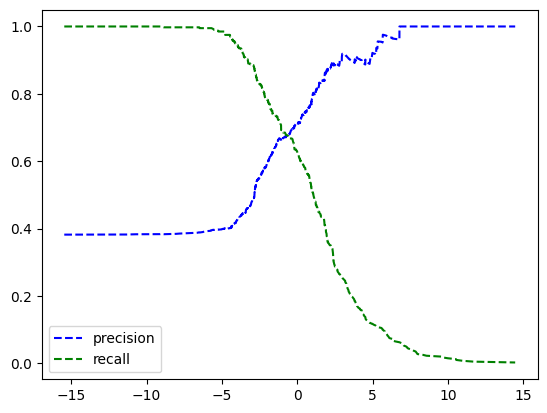

In [26]:
plt.plot(thresholds , precisions[:-1] , 'b--' , label='precision')
plt.plot(thresholds , recalls[:-1] , 'g--' , label='recall')
plt.legend()

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
forest_clf = make_pipeline(preprocessing , RandomForestClassifier(n_estimators=200))
forest_clf.fit(X_train , y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a8930621190>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a893c0d0770>)])),
                ('randomforestclassifier',
                 RandomForestClassifier(n_estimators=200))])

In [29]:
forest_train_pred = cross_val_score(forest_clf , X_train , y_train , cv=3 , scoring='accuracy')

In [30]:
forest_scores = cross_val_predict(forest_clf , X_train , y_train , cv=3 , method='predict_proba')[: , 1]

In [31]:
forest_scores

array([0.53572136, 0.9531694 , 0.12980619, ..., 0.15122807, 0.25000057,
       0.07583374], shape=(1047,), dtype=float32)

In [32]:
forest_precision , forest_recall , forest_threshold = precision_recall_curve(y_train , forest_scores , pos_label='1')

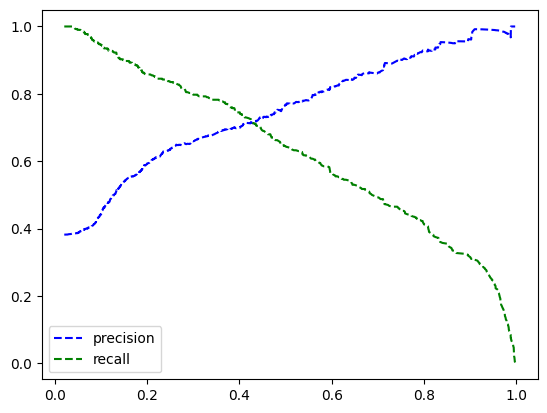

In [33]:
plt.plot(forest_threshold , forest_precision[:-1] , 'b--' , label='precision')
plt.plot(forest_threshold , forest_recall[:-1] , 'g--' , label='recall')
plt.legend()

In [34]:
y_forest_f1 = forest_clf.predict(X_train)

In [35]:
y_forest_f1

array(['1', '1', '0', ..., '0', '0', '0'], shape=(1047,), dtype=object)

In [36]:
f1_score(y_train , y_forest_f1 , pos_label='1')

0.8575268817204301

In [37]:
!pip install -q gradio

import gradio as gr
import pandas as pd

def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked):
    data = pd.DataFrame([{
        'pclass': str(pclass),
        'sex': sex.lower(),
        'age': float(age),
        'sibsp': int(sibsp),
        'parch': int(parch),
        'fare': float(fare),
        'embarked': embarked
    }])
    pred = forest_clf.predict(data)[0]
    prob = forest_clf.predict_proba(data)[0][1]
        
    status = "🎉 SURVIVED" if pred == '1' else "😢 DIED"
    print(f"Result: {status}\nSurvival Probability: {prob * 100:.1f}%")
        
interface = gr.Interface(
    fn=predict_survival,
    inputs=[
        gr.Dropdown(choices=["1", "2", "3"], label="Passenger Class"),
        gr.Dropdown(choices=["Male", "Female"], label="Sex"),
        gr.Slider(minimum=0, maximum=100, value=25, step=1, label="Age"),
        gr.Number(value=0, precision=0, label="Siblings / Spouses Aboard"),
        gr.Number(value=0, precision=0, label="Parents / Children Aboard"),
        gr.Slider(minimum=0, maximum=512, value=32, label="Ticket Fare ($)"),
        gr.Radio(choices=["S", "C", "Q"], label="Port of Embarkation")
    ],
    outputs=gr.Textbox(label="Model Prediction", lines=2),
    title="🚢 Titanic Survival Predictor Dashboard",
    description="Adjust the passenger inputs below to see real-time survival predictions from your trained Random Forest pipeline.",
    flagging_mode="never"
)

# Launch directly inside the Kaggle notebook cell output
interface.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://713fc52f56beb6c522.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
